# Scenario Comparison Analysis

In [1]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [3]:
cluster = "450"
home = "/home/lucakristin/Desktop/my_pypsa"

In [ ]:
wind_opt = "windy" #or "not-windy" or "wind-variability"

base_config_name = f"germany_base_{wind_opt}" #or "germany_base_notwindy" or "germany_base_windvariability"
scenario_config_name = f"germany_scenario_{wind_opt}" #or "germany_scenario_{wind_opt}_lines_extendable" or "germany_scenario_{wind_opt}_lines_fixed"

# Load solved networks

In [ ]:
# --- Load Base Network ---
base_network_path = f"{home}/pypsa-eur/results/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
n_base = pypsa.Network(base_network_path, name="Base Network")
n_base.name = "Base Network"

# --- Load Scenario Network ---
scenario_network_path = f"{home}/pypsa-eur/results/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
n_scenario = pypsa.Network(scenario_network_path, name="Scenario Network")
n_scenario.name = "Scenario Network"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


In [7]:
base_network_path1 = f"{home}/pypsa-eur/results/germany_base_windy/networks/base_s_{cluster}_elec_.nc"
n1 = pypsa.Network(base_network_path1)

base_network_path2 = f"{home}/pypsa-eur/results/germany_base_notwindy/networks/base_s_{cluster}_elec_.nc"
n2 = pypsa.Network(base_network_path2)

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


## 4. Comparison Plots

### 4.1 Grid Congestion and Curtailment

In [227]:
if n_base.lines.s_nom_opt.sum() == n_scenario.lines.s_nom_opt.sum():
    print("Line capacities are the same in both networks.")
else:
    print("Line capacities differ between the two networks.")

Line capacities differ between the two networks.


##### Line Loading Comparison

Base Network - Average Line Loading (All Snapshots)
name
DE0 0             19.014562
DE0 1              0.012160
DE0 10            13.912554
DE0 100            0.025812
DE0 101           14.893596
                    ...    
DE0 95 battery     8.986183
DE0 96 battery     0.064744
DE0 97 battery     0.053816
DE0 98 battery    10.405934
DE0 99 battery    11.978321
Name: 2025-10-26 17:00:00, Length: 1350, dtype: float64
Scenario Network - Average Line Loading (All Snapshots)
name
DE0 0             34.109193
DE0 1             34.119213
DE0 10            34.019308
DE0 100           34.115558
DE0 101           33.814659
                    ...    
DE0 95 battery    31.813998
DE0 96 battery    31.788591
DE0 97 battery    31.835082
DE0 98 battery    31.794119
DE0 99 battery    31.797693
Name: 2025-04-08 05:00:00, Length: 1350, dtype: float64


KeyError: Timestamp('2025-10-26 08:00:00')

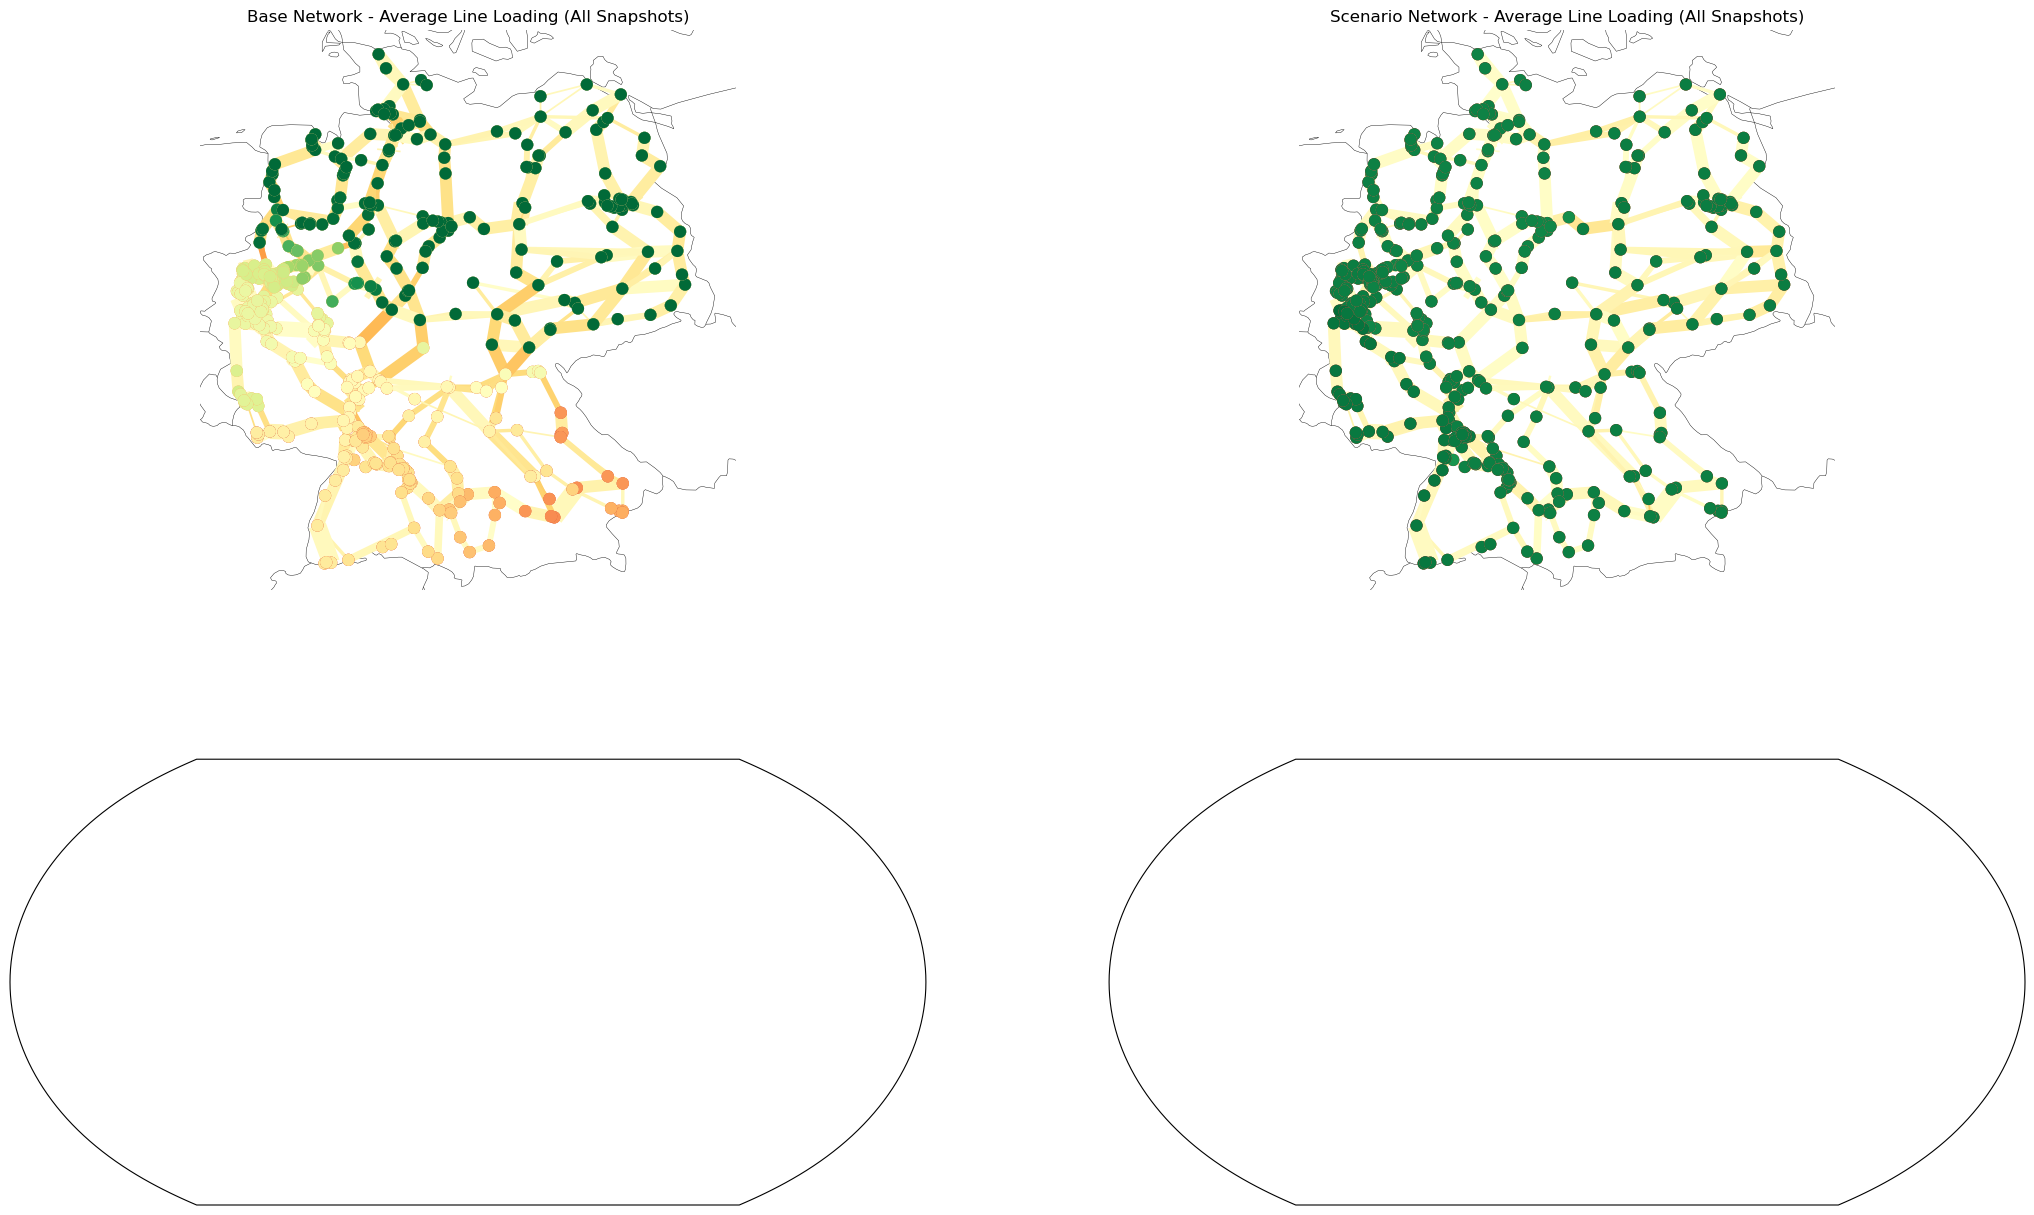

In [12]:
snapshot = n1.snapshots[8]

bus_size_factor = 1e9
branch_width_factor = 400

nom_base  = n1.lines.s_nom
nom_scenario = n2.lines.s_nom

# --- Calculate average loading across all snapshots ---
avg_loading_base = (n1.lines_t.p0.abs() / nom_base).mean()
avg_loading_scenario = (n2.lines_t.p0.abs() / nom_scenario).mean()

# --- Identify congested lines (>80% and >90% of capacity) ---
congested_80_base = avg_loading_base[avg_loading_base > 0.8].sort_values(ascending=False)
congested_80_scenario = avg_loading_scenario[avg_loading_scenario > 0.8].sort_values(ascending=False)

# --- Create enhanced visualization ---
fig, axes = plt.subplots(2, 2, figsize=(26, 16), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title, is_difference=False):
    # Calculate energy balance for bus sizes
    eb = (
        n.statistics.energy_balance(
            groupby=["bus", "carrier"],
            components=["Generator", "Load", "StorageUnit"],
        )
        .groupby(["bus", "carrier"])
        .sum()
    )

    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]

    print("=" * 70)
    print(title)
    print(peak_prices)
    print("=" * 70)
    
    if is_difference:
        # For difference plot
        n.plot(
            ax=ax,
            geomap=True,
            title=title,
            bus_sizes=0,

            line_colors=loading_avg,
            line_cmap="RdYlGn_r",  # Red for high differences, green for low
            line_width=4,
            link_width=4,
        )
    else:
        # For loading plots
        n.plot(
            ax=ax,
            geomap=True,
            title=title,
            bus_sizes=0.01, # Size buses by marginal price
            bus_colors=peak_prices,       # Color buses by marginal price
            bus_cmap='RdYlGn_r',
            line_colors=loading_avg,
            line_cmap="YlOrRd",  # Yellow to Red for increasing congestion
            line_width=n.lines.s_nom / branch_width_factor,
            link_width=n.links.p_nom / branch_width_factor,
        )

# Row 1: Average Loading Over All Snapshots
plot_network_congestion(n1, avg_loading_base, axes[0, 0], 
                        "Base Network - Average Line Loading (All Snapshots)")
plot_network_congestion(n2, avg_loading_scenario, axes[0, 1], 
                        "Scenario Network - Average Line Loading (All Snapshots)")

# Row 2, Col 1: Single snapshot for context
loading_base_snapshot = n1.lines_t.p0.loc[snapshot].abs() / nom_base
loading_scenario_snapshot = n2.lines_t.p0.loc[snapshot].abs() / nom_scenario

plot_network_congestion(n1, loading_base_snapshot, axes[1, 0], 
                        f"Base Network - Line Loading at {snapshot}")

# Row 2, Col 2: Difference in average loading
loading_diff_avg = (avg_loading_scenario - avg_loading_base).abs()
plot_network_congestion(n1, loading_diff_avg, axes[1, 1], 
                        "Difference in Average Line Loading\n(Scenario vs Base)", 
                        is_difference=True)


coal_max_lat = 52
onwind_min_lat = None


# --- Draw latitude marker lines on all map axes if latitudes are available ---
for ax in axes.flat:
    try:
        lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
    except Exception:
        lon_min, lon_max = -11, 35
    if coal_max_lat is not None:
        ax.plot([lon_min, lon_max], [coal_max_lat, coal_max_lat], transform=ccrs.PlateCarree(),
                color='navy', linestyle='--', linewidth=2)
        ax.text(lon_max, coal_max_lat, ' coal max lat', transform=ccrs.PlateCarree(),
                va='center', ha='right', color='navy', fontsize=9, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    if onwind_min_lat is not None:
        ax.plot([lon_min, lon_max], [onwind_min_lat, onwind_min_lat], transform=ccrs.PlateCarree(),
                color='darkgreen', linestyle='-.', linewidth=2)
        ax.text(lon_max, onwind_min_lat, ' onwind min lat', transform=ccrs.PlateCarree(),
                va='center', ha='right', color='darkgreen', fontsize=9, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.tight_layout()
plt.show()


In [13]:

# --- Print congestion statistics ---
print("\n" + "=" * 70)
print("CONGESTION STATISTICS")
print("=" * 70)
print(f"\nBase Network:")
print(f"  Average loading across all lines: {avg_loading_base.mean():.2%}")
print(f"  Max average loading: {avg_loading_base.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_base > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_base > 0.7).sum()}")

print(f"\nScenario Network:")
print(f"  Average loading across all lines: {avg_loading_scenario.mean():.2%}")
print(f"  Max average loading: {avg_loading_scenario.max():.2%}")
print(f"  Lines with >60% avg loading: {(avg_loading_scenario > 0.6).sum()}")
print(f"  Lines with >70% avg loading: {(avg_loading_scenario > 0.7).sum()}")

print(f"\nDifference (Scenario - Base):")
print(f"  Max increase in loading: {(avg_loading_scenario - avg_loading_base).max():.2%}")
print(f"  Max decrease in loading: {(avg_loading_scenario - avg_loading_base).min():.2%}")
print("=" * 70)


CONGESTION STATISTICS

Base Network:
  Average loading across all lines: 29.47%
  Max average loading: 243.55%
  Lines with >60% avg loading: 58
  Lines with >70% avg loading: 23

Scenario Network:
  Average loading across all lines: 15.45%
  Max average loading: 313.40%
  Lines with >60% avg loading: 6
  Lines with >70% avg loading: 4

Difference (Scenario - Base):
  Max increase in loading: 230.41%
  Max decrease in loading: -165.53%


No generator carrier containing 'load' found. Plot will show zeros.
No generator carrier containing 'load' found. Plot will show zeros.


KeyError: Timestamp('2025-10-26 08:00:00')

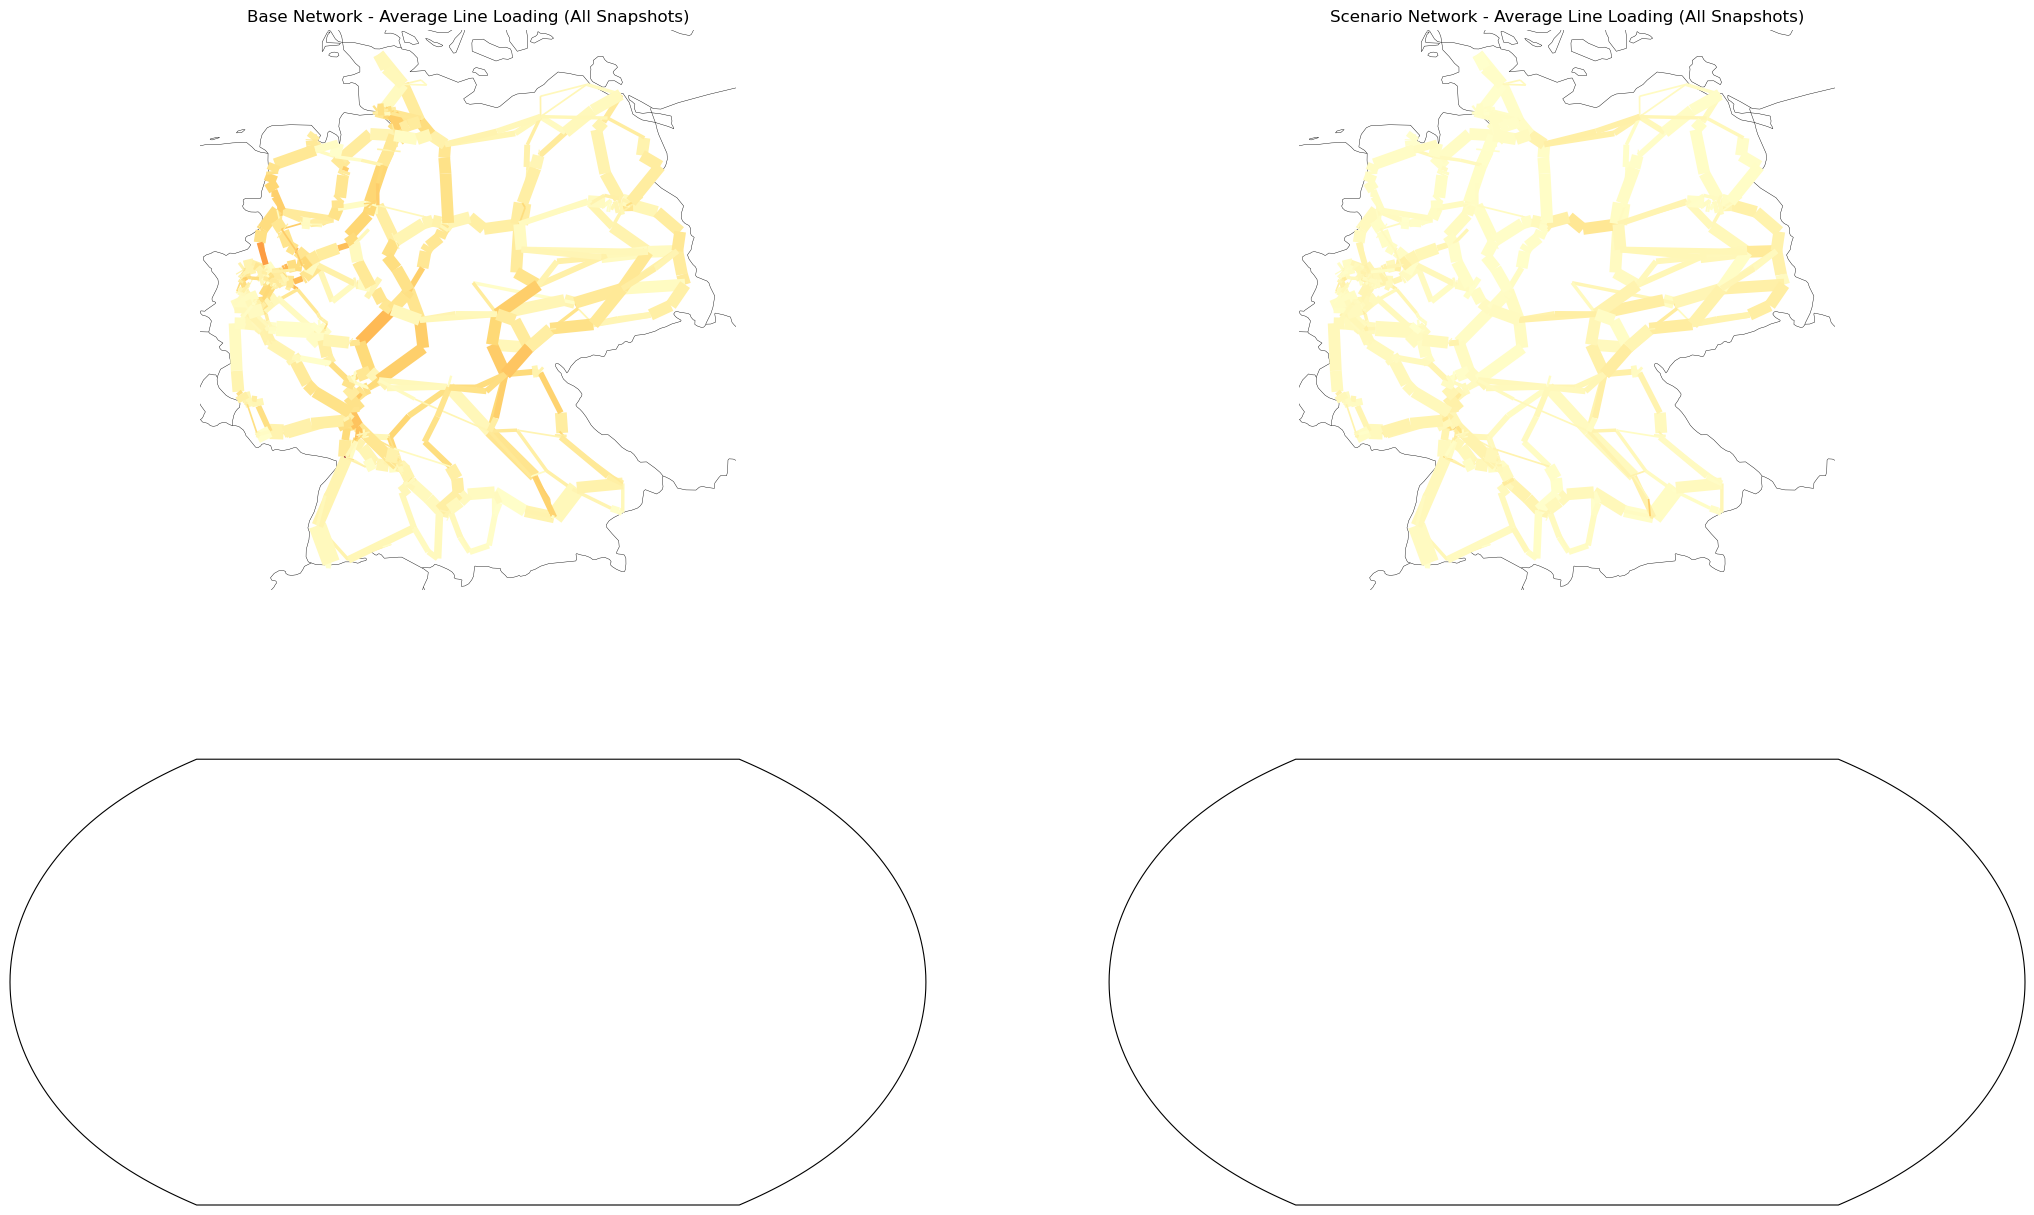

In [14]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(2, 2, figsize=(26, 16), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, loading_avg, ax, title, is_difference=False):
    # Calculate energy balance for bus sizes
    eb = (
        n.statistics.energy_balance(
            groupby=["bus", "carrier"],
            components=["Generator", "Load", "StorageUnit"],
        )
        .groupby(["bus", "carrier"])
        .sum()
    )

    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        used_carriers = sorted(n.generators.loc[shed_gens, "carrier"].unique())
        print(f"Using load-related carriers: {used_carriers}")

        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"])
            .sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )

    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]

    
    if is_difference:
        # For difference plot
        n.plot(
            ax=ax,
            geomap=True,
            title=title,
            bus_sizes=0,

            line_colors=loading_avg,
            line_cmap="coolwarm",  # Red for high differences, green for low
            line_width=4,
            link_width=4,
        )
    else:
        # For loading plots
        n.plot(
            ax=ax,
            geomap=True,
            title=title,
            #bus_sizes=0.01, # Size buses by unmet load at worst snapshot
            bus_sizes=unmet_load_at_snapshot/5000,
            #bus_colors=unmet_load_at_snapshot,
            bus_alpha=0.5,
            bus_cmap="YlOrRd",
            line_colors=loading_avg,
            line_cmap="YlOrRd",  # Yellow to Red for increasing congestion
            line_width=n.lines.s_nom / branch_width_factor,
            link_width=n.links.p_nom / branch_width_factor,
        )

# Row 1: Average Loading Over All Snapshots
plot_network_congestion(n1, avg_loading_base, axes[0, 0], 
                        "Base Network - Average Line Loading (All Snapshots)")
plot_network_congestion(n2, avg_loading_scenario, axes[0, 1], 
                        "Scenario Network - Average Line Loading (All Snapshots)")

# Row 2, Col 1: Single snapshot for context
loading_base_snapshot = n1.lines_t.p0.loc[snapshot].abs() / nom_base
loading_scenario_snapshot = n2.lines_t.p0.loc[snapshot].abs() / nom_scenario

plot_network_congestion(n1, loading_base_snapshot, axes[1, 0], 
                        f"Base Network - Line Loading at {snapshot}")

# Row 2, Col 2: Difference in average loading
loading_diff_avg = (avg_loading_scenario - avg_loading_base).abs()
plot_network_congestion(n1, loading_diff_avg, axes[1, 1], 
                        "Difference in Average Line Loading\n(Scenario vs Base)", 
                        is_difference=True)


coal_max_lat = 52
onwind_min_lat = 52


# --- Draw latitude marker lines on all map axes if latitudes are available ---
for ax in axes.flat:
    try:
        lon_min, lon_max, lat_min, lat_max = ax.get_extent(ccrs.PlateCarree())
    except Exception:
        lon_min, lon_max = -11, 35
    if coal_max_lat is not None:
        ax.plot([lon_min, lon_max], [coal_max_lat, coal_max_lat], transform=ccrs.PlateCarree(),
                color='navy', linestyle='--', linewidth=2)
        ax.text(lon_max, coal_max_lat, ' coal max lat', transform=ccrs.PlateCarree(),
                va='center', ha='right', color='navy', fontsize=9, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    if onwind_min_lat is not None:
        ax.plot([lon_min, lon_max], [onwind_min_lat, onwind_min_lat], transform=ccrs.PlateCarree(),
                color='darkgreen', linestyle='-.', linewidth=2)
        ax.text(lon_max, onwind_min_lat, ' onwind min lat', transform=ccrs.PlateCarree(),
                va='center', ha='right', color='darkgreen', fontsize=9, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.tight_layout()
plt.show()

In [15]:
# Check actual demand vs what was satisfied
load_shed = n2.loads_t.p_set.sum(axis=1) - n2.loads_t.p.sum(axis=1)
print(f"Total load shed: {load_shed.sum():.2f} MWh")
print(f"Max hourly load shed: {load_shed.max():.2f} MW")
print(f"Hours with shedding: {(load_shed > 0.1).sum()}")

Total load shed: 0.00 MWh
Max hourly load shed: 0.00 MW
Hours with shedding: 0


##### Offshore Wind Curtailment

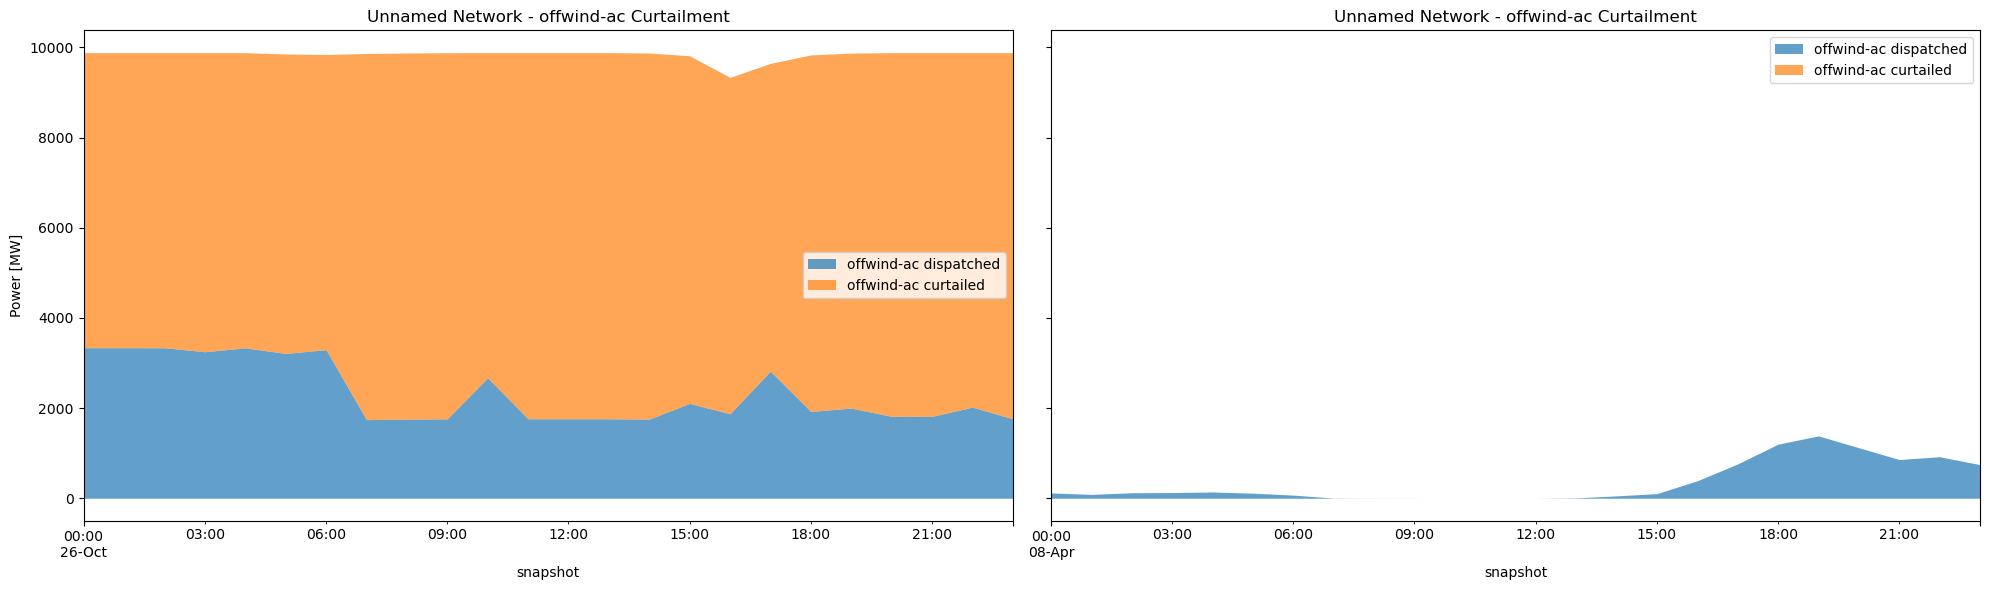

In [16]:
def plot_curtailment(n, carrier, ax):
    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    p_dispatched = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed = p_available - p_dispatched
    
    # Correct for any minor negative values from floating point inaccuracies
    p_curtailed[p_curtailed < 0] = 0
    
    df = pd.DataFrame({
        f"{carrier} dispatched": p_dispatched[carrier],
        f"{carrier} curtailed": p_curtailed[carrier]
    })
    
    df.plot(kind="area", ax=ax, lw=0, alpha=0.7)
    ax.set_title(f"{n.name} - {carrier} Curtailment")
    ax.set_ylabel("Power [MW]")

fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])

plt.tight_layout()
plt.show()

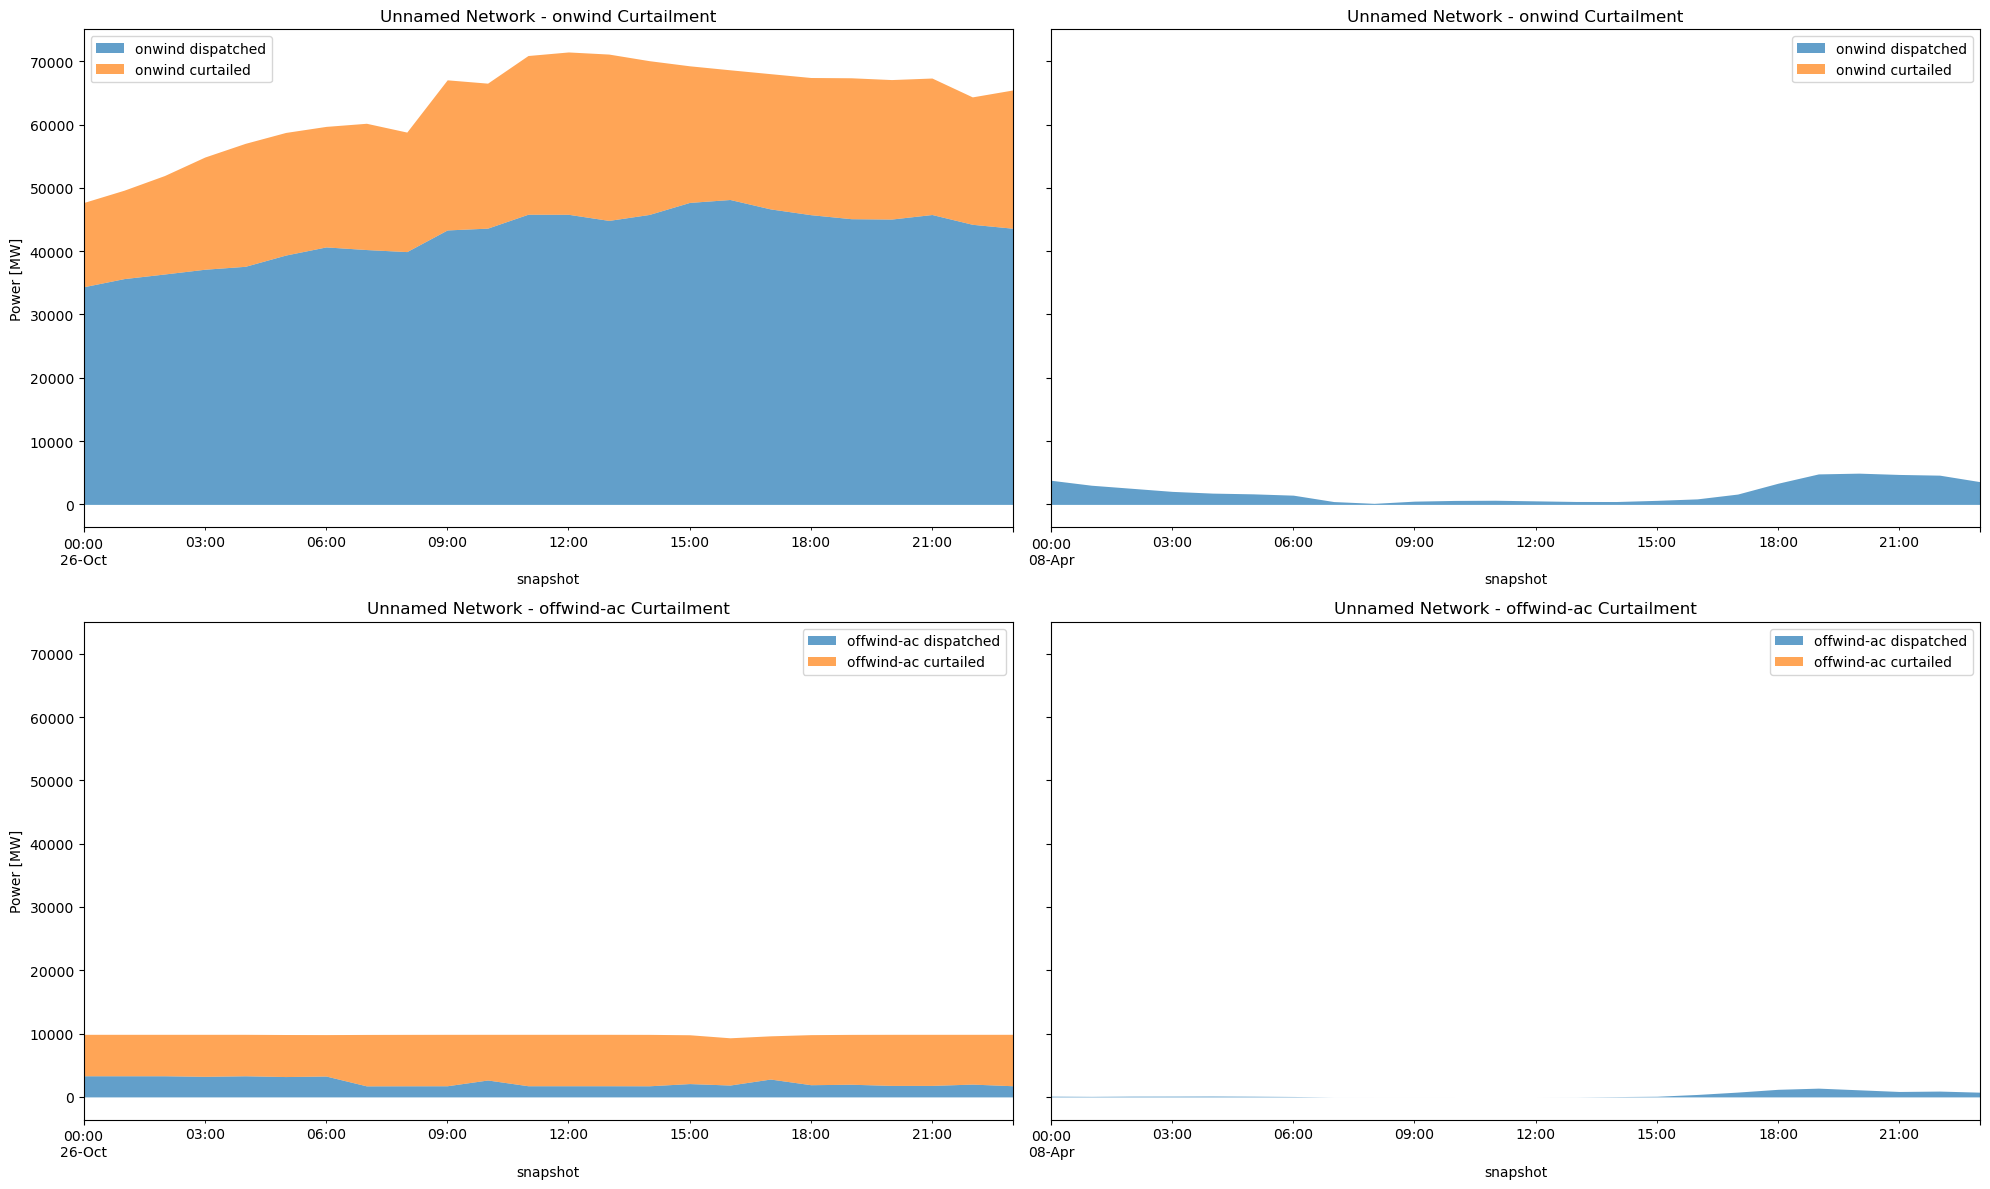

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)

plot_curtailment(n1, "onwind", axes[0, 0])
plot_curtailment(n2, "onwind", axes[0, 1])
plot_curtailment(n1, "offwind-ac", axes[1, 0])
plot_curtailment(n2, "offwind-ac", axes[1, 1])

plt.tight_layout()
plt.show()

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

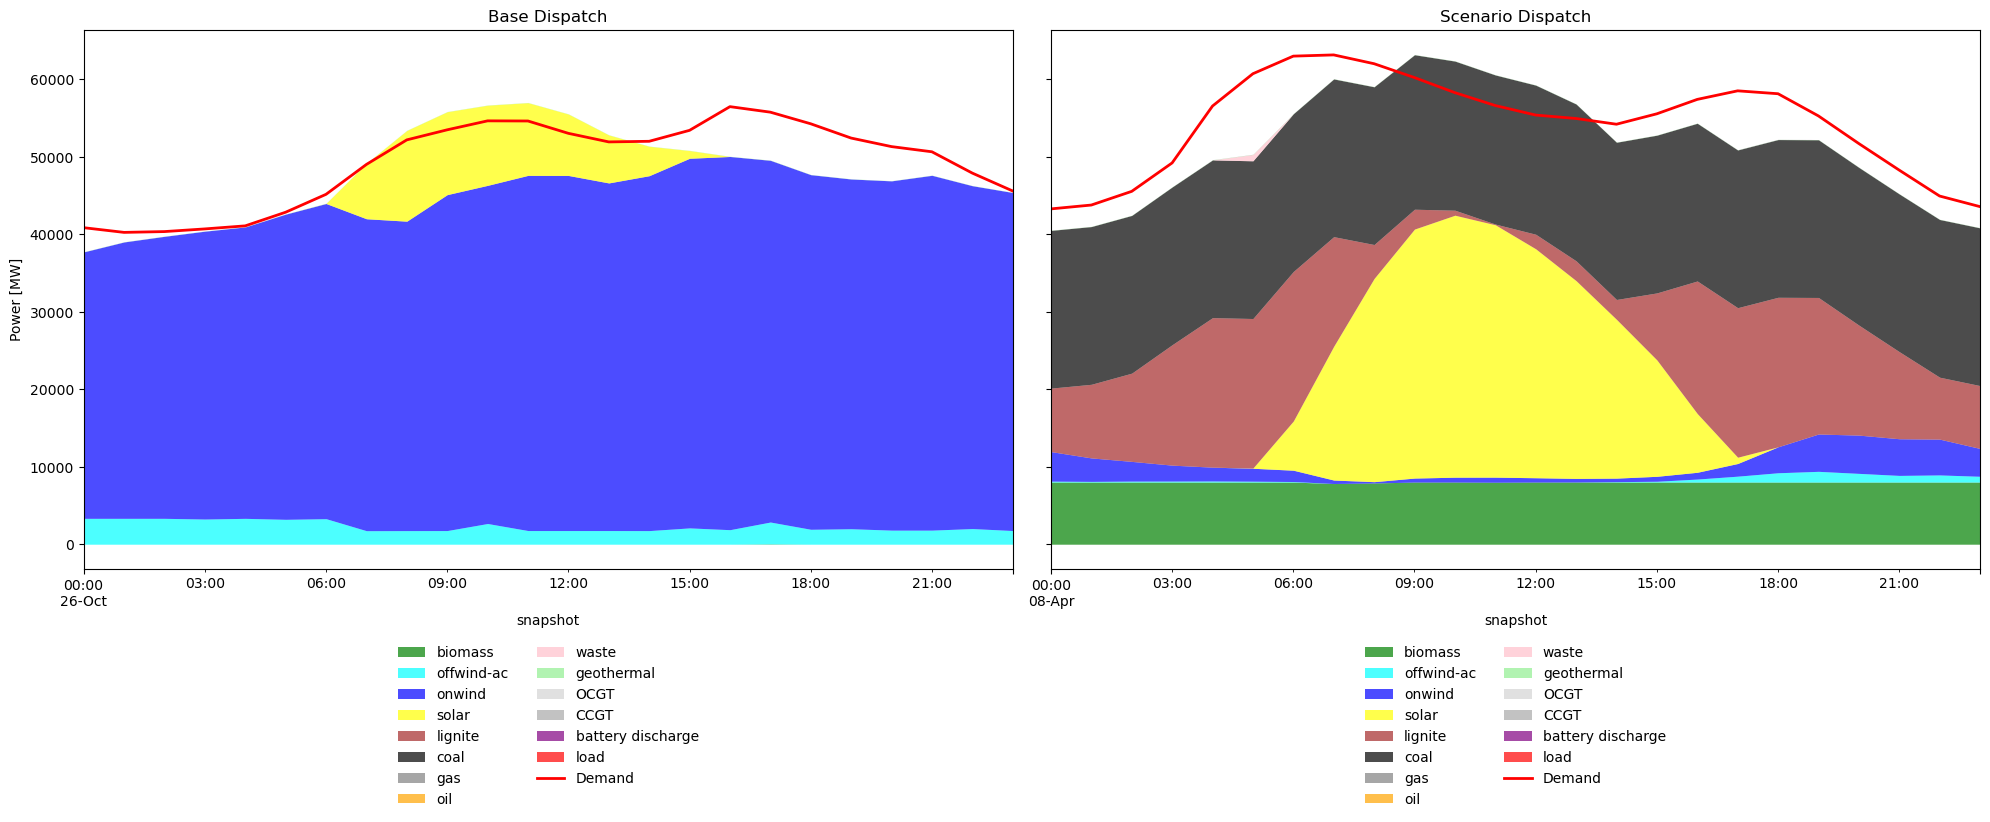

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    "biomass": "green", "coal": "black", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "gray", "oil": "orange", "waste": "pink", "geothermal": "lightgreen",
    "OCGT": "lightgray", "CCGT": "darkgray", "battery discharge": "purple", "load": "red"
}

cols = [
    "biomass", "offwind-ac", "onwind", "solar", "lignite", "coal", "gas", "oil", "waste", "geothermal", "OCGT", "CCGT", "battery discharge", "load"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="red", lw=2, label="Demand")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n1, axes[0], "Base Dispatch")
plot_dispatch(n2, axes[1], "Scenario Dispatch")

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

##### Total Energy Production by Carrier

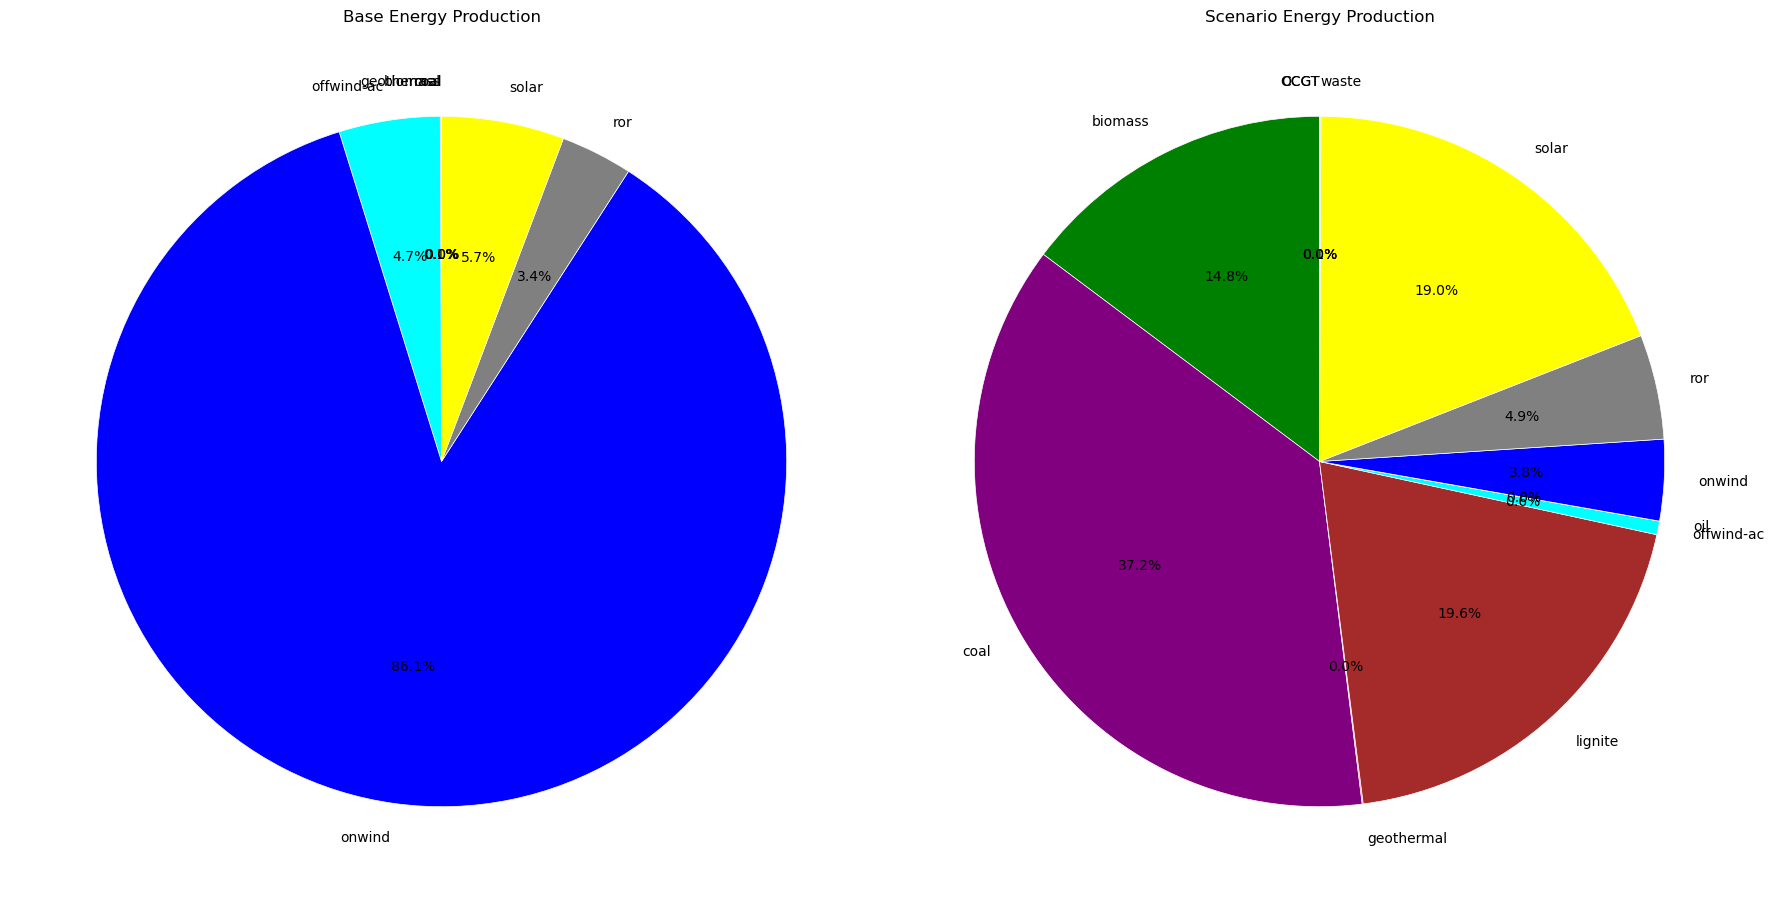

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# --- Define Colors and Order (same as dispatch plot) ---
colors = {
    "biomass": "green", "coal": "purple", "lignite": "brown",
    "offwind-ac": "cyan", "onwind": "blue", "solar": "yellow",
    "gas": "purple", "oil": "orange", "waste": "pink", "geothermal": "red",
    "OCGT": "lightgray", "CCGT": "darkgray", "load": "red"
}

# --- Helper function for plotting pie chart ---
def plot_energy_pie(p_by_carrier, ax, title):
    energy_total = p_by_carrier.sum()
    # Filter out carriers with zero or negligible energy
    energy_total = energy_total[energy_total > 0.1]
    
    # Get colors for the carriers that are present
    pie_colors = [colors.get(carrier, "grey") for carrier in energy_total.index]

    energy_total.plot(
        kind="pie", 
        ax=ax, 
        autopct='%1.1f%%', 
        startangle=90, 
        title=title,
        colors=pie_colors,
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'} # Add white borders for clarity
    )
    ax.set_ylabel("")

# --- Calculate energy production for each scenario ---
p_by_carrier_base = n1.generators_t.p.T.groupby(n1.generators.carrier).sum().T
p_by_carrier_scenario = n2.generators_t.p.T.groupby(n2.generators.carrier).sum().T


# --- Plotting ---
plot_energy_pie(p_by_carrier_base, axes[0], "Base Energy Production")
plot_energy_pie(p_by_carrier_scenario, axes[1], "Scenario Energy Production")


plt.tight_layout()
plt.show()

### 4.3 Energy Balance


##### Unserved Energy Analysis


In [24]:
# --- Get Data ---
# Total generation from power plants
total_generation = p_by_carrier_scenario.sum(axis=1)

# Power consumed by Link components
link_dispatch = n_scenario.links_t.p0.T.groupby(n_scenario.links.carrier).sum().T
link_dispatch = link_dispatch.loc[:, (link_dispatch.abs().sum() > 0.1)]

# Isolate battery charging and discharging
battery_charge = link_dispatch['battery charger'] if 'battery charger' in link_dispatch else pd.Series(0, index=link_dispatch.index)
# Discharging is negative from the link's perspective, so we make it positive
battery_discharge = -link_dispatch['battery discharger'] if 'battery discharger' in link_dispatch else pd.Series(0, index=link_dispatch.index)

# Electricity demand
demand = n_scenario.loads_t.p_set.sum(axis=1)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(15, 7))

# Plot Demand and Generation as lines
ax.plot(demand.index, demand, color='red', lw=2, label='Demand')
ax.plot(total_generation.index, total_generation, color='blue', lw=2, label='Total Generation')


# --- Final Touches ---
ax.set_title('Scenario Energy Balance')
ax.set_ylabel('Power [MW]')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


NameError: name 'n_scenario' is not defined

In [238]:
# Build an electricity-system balance per bus and snapshot.
def _group_sum(df, labels):
    if df.empty:
        return pd.DataFrame(index=n_scenario.snapshots)
    return df.T.groupby(labels).sum().T

bus_balance = _group_sum(n_scenario.generators_t.p, n_scenario.generators.bus)
bus_balance = bus_balance.add(-_group_sum(n_scenario.loads_t.p_set, n_scenario.loads.bus), fill_value=0)

if not n_scenario.storage_units.empty:
    bus_balance = bus_balance.add(_group_sum(n_scenario.storage_units_t.p, n_scenario.storage_units.bus), fill_value=0)

if not n_scenario.stores.empty:
    bus_balance = bus_balance.add(_group_sum(n_scenario.stores_t.p, n_scenario.stores.bus), fill_value=0)

if not n_scenario.links.empty:
    bus_balance = bus_balance.add(-_group_sum(n_scenario.links_t.p0, n_scenario.links.bus0), fill_value=0)
    bus_balance = bus_balance.add(-_group_sum(n_scenario.links_t.p1, n_scenario.links.bus1), fill_value=0)

if not n_scenario.lines.empty:
    bus_balance = bus_balance.add(-_group_sum(n_scenario.lines_t.p0, n_scenario.lines.bus0), fill_value=0)
    bus_balance = bus_balance.add(-_group_sum(n_scenario.lines_t.p1, n_scenario.lines.bus1), fill_value=0)

if not n_scenario.transformers.empty:
    bus_balance = bus_balance.add(-_group_sum(n_scenario.transformers_t.p0, n_scenario.transformers.bus0), fill_value=0)
    bus_balance = bus_balance.add(-_group_sum(n_scenario.transformers_t.p1, n_scenario.transformers.bus1), fill_value=0)

# Residual balance per hour after summing across all buses.
hourly_residual = bus_balance.sum(axis=1)

# Report absolute and relative size of the mismatch.
total_abs_residual_mwh = hourly_residual.abs().sum()
total_residual_mwh = hourly_residual.sum()
peak_hourly_residual_mw = hourly_residual.abs().max()
relative_residual_pct = 100 * total_abs_residual_mwh / demand.sum()

print("--- Full Bus Balance Check (Scenario) ---")
print(f"Total absolute residual: {total_abs_residual_mwh:,.2f} MWh")
print(f"Net residual over horizon: {total_residual_mwh:,.2f} MWh")
print(f"Peak hourly residual: {peak_hourly_residual_mw:,.2f} MW")
print(f"Residual as share of total demand: {relative_residual_pct:.4f}%")
print("----------------------------------------------------")

if total_abs_residual_mwh < 1 and peak_hourly_residual_mw < 1:
    print("The remaining imbalance is just numerical noise.")
elif relative_residual_pct < 0.1:
    print("The residual is small relative to total demand and can likely be neglected in the overall picture.")
else:
    print("The residual is not negligible and should be investigated further.")

# Optional: show the buses with the largest net residual over the horizon.
bus_residual = bus_balance.sum(axis=0).sort_values(key=lambda s: s.abs(), ascending=False)
print("\nTop buses by net residual over the horizon:")
print(bus_residual.head(10))

--- Full Bus Balance Check (Scenario) ---
Total absolute residual: 0.00 MWh
Net residual over horizon: -0.00 MWh
Peak hourly residual: 0.00 MW
Residual as share of total demand: 0.0000%
----------------------------------------------------
The remaining imbalance is just numerical noise.

Top buses by net residual over the horizon:
DE0 0     -7.680967e-11
DE0 126    6.144418e-11
DE0 181   -5.456968e-11
DE0 117    5.377743e-11
DE0 250   -5.002221e-11
DE0 358   -4.471801e-11
DE0 255    3.745981e-11
DE0 135   -3.487033e-11
DE0 8     -3.337523e-11
DE0 203    3.228706e-11
dtype: float64


In [239]:
#n_scenario.components.buses.static